c:\Users\Noora\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


c:\Users\Noora\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


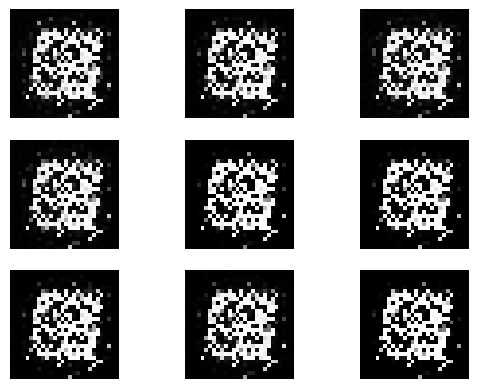

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train, _), (_, _) = keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)

generator = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(100,)),
    keras.layers.Dense(28*28, activation='sigmoid'),
    keras.layers.Reshape((28,28,1))
])

discriminator = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28,1)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

discriminator.compile(optimizer='adam', loss='binary_crossentropy')

discriminator.trainable = False
gan = keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

for epoch in range(500):
    noise = np.random.normal(0, 1, (32, 100))
    fake = generator.predict(noise, verbose=0)
    real = x_train[np.random.randint(0, x_train.shape[0], 32)]

    X = np.concatenate([real, fake])
    y = np.concatenate([np.ones(32), np.zeros(32)])

    discriminator.trainable = True
    discriminator.train_on_batch(X, y)

    noise = np.random.normal(0, 1, (32, 100))
    y_gen = np.ones(32)

    discriminator.trainable = False
    gan.train_on_batch(noise, y_gen)

noise = np.random.normal(0, 1, (9, 100))
gen_images = generator.predict(noise)

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(gen_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()